In [3]:
import pandas as pd

df = pd.read_csv("2010.csv", encoding="latin1")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 2765
Columns: 15


,Reference Number,Easting,Northing,Number of Vehicles,Accident Date,Time (24hr),1st Road Class,Road Surface,Lighting Conditions,Weather Conditions,Casualty Class,Casualty Severity,Sex of Casualty,Age of Casualty,Type of Vehicle
0,10BA0000011,430408,437054,2,01-Jan-10,1650,Unclassified,Wet / Damp,Darkness: street lights present and lit,Snowing without high winds,Driver,Slight,Female,62,Car
1,10BA0000014,435011,436276,2,01-Jan-10,205,Unclassified,Wet / Damp,Darkness: street lights present and lit,Fine without high winds,Passenger,Slight,Male,36,Goods vehicle 3.5 tonnes mgw and under
2,10BA0000037,430429,437764,1,01-Jan-10,124,Unclassified,Frost/ Ice,Darkness: street lights present and lit,Fine without high winds,Pedestrian,Slight,Female,34,Goods vehicle 3.5 tonnes mgw and under
3,10BA0000064,429002,436842,2,01-Jan-10,550,Unclassified,Wet / Damp,Darkness: street lights present and lit,Fine without high winds,Driver,Slight,Male,27,Car
4,10CA0000023,429399,433811,2,01-Jan-10,1825,A(M),Wet / Damp,Darkness: street lights present and lit,Fine without high winds,Driver,Slight,Male,18,Car


In [4]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

Column names:
['Reference Number', 'Easting', 'Northing', 'Number of Vehicles', 'Accident Date', 'Time (24hr)', '1st Road Class', 'Road Surface', 'Lighting Conditions', 'Weather Conditions', 'Casualty Class', 'Casualty Severity', 'Sex of Casualty', 'Age of Casualty', 'Type of Vehicle']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2765 entries, 0 to 2764
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Reference Number     2765 non-null   object
 1   Easting              2765 non-null   int64 
 2   Northing             2765 non-null   int64 
 3   Number of Vehicles   2765 non-null   int64 
 4   Accident Date        2765 non-null   object
 5   Time (24hr)          2765 non-null   int64 
 6   1st Road Class       2765 non-null   object
 7   Road Surface         2765 non-null   object
 8   Lighting Conditions  2765 non-null   object
 9   Weather Conditions   2765 non-null   obj

In [5]:
df.shape

(2765, 15)

In [6]:
# Convert Accident Date to datetime
df["Accident Date"] = pd.to_datetime(df["Accident Date"], errors="coerce")

# Create a readable time-of-day column
def get_time_period(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df["Time Period"] = df["Time (24hr)"].apply(get_time_period)

# Check the result
print(df[["Accident Date", "Time (24hr)", "Time Period"]].head(10))

  Accident Date  Time (24hr) Time Period
0    2010-01-01         1650       Night
1    2010-01-01          205       Night
2    2010-01-01          124       Night
3    2010-01-01          550       Night
4    2010-01-01         1825       Night
5    2010-01-01         1825       Night
6    2010-01-01         1825       Night
7    2010-01-01         1715       Night
8    2010-01-01         1715       Night
9    2010-01-01         1715       Night


/tmp/ipykernel_566/1266569366.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Accident Date"] = pd.to_datetime(df["Accident Date"], errors="coerce")


In [7]:
def get_time_period(time):
    hour = int(time) // 100

    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 21:
        return "Evening"
    else:
        return "Night"

df["Time Period"] = df["Time (24hr)"].apply(get_time_period)

print(df[["Time (24hr)", "Time Period"]].head(10))

   Time (24hr) Time Period
0         1650   Afternoon
1          205       Night
2          124       Night
3          550     Morning
4         1825     Evening
5         1825     Evening
6         1825     Evening
7         1715     Evening
8         1715     Evening
9         1715     Evening


In [8]:
df["Time Period"].value_counts()

,count
Time Period,
Afternoon,972
Evening,718
Morning,675
Night,400


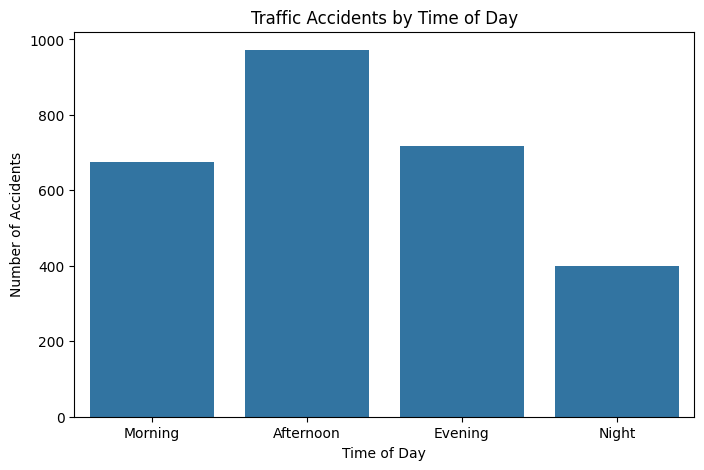

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Time Period", order=["Morning", "Afternoon", "Evening", "Night"])

plt.title("Traffic Accidents by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Number of Accidents")

plt.savefig("Accidents_by_Time_of_Day.png", bbox_inches="tight")
plt.show()

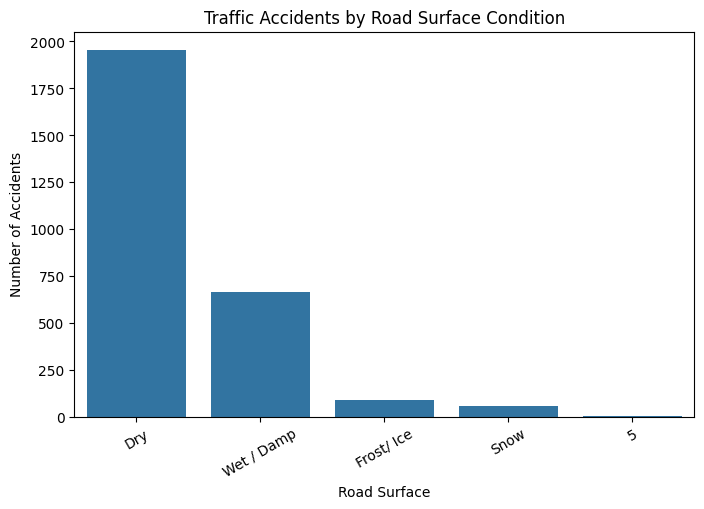

In [10]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Road Surface",
    order=df["Road Surface"].value_counts().index
)

plt.title("Traffic Accidents by Road Surface Condition")
plt.xlabel("Road Surface")
plt.ylabel("Number of Accidents")
plt.xticks(rotation=30)

plt.savefig("Accidents_by_Road_Surface.png", bbox_inches="tight")
plt.show()

/tmp/ipykernel_566/1679678229.py:14: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  plt.savefig("Accidents_by_Weather_Conditions.png", bbox_inches="tight")
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 150 (\x96) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


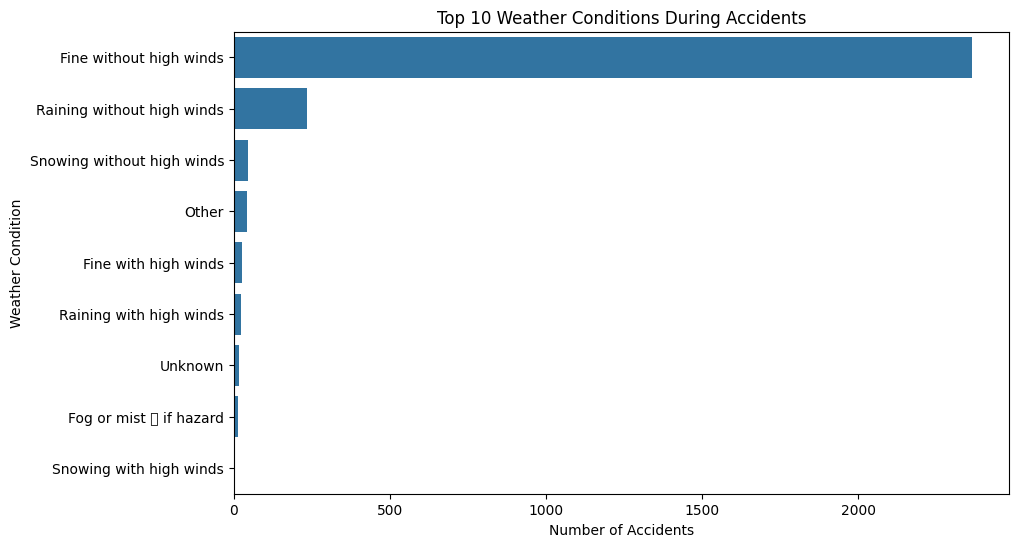

In [11]:
plt.figure(figsize=(10, 6))

weather_counts = df["Weather Conditions"].value_counts().head(10)

sns.barplot(
    x=weather_counts.values,
    y=weather_counts.index
)

plt.title("Top 10 Weather Conditions During Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("Weather Condition")

plt.savefig("Accidents_by_Weather_Conditions.png", bbox_inches="tight")
plt.show()

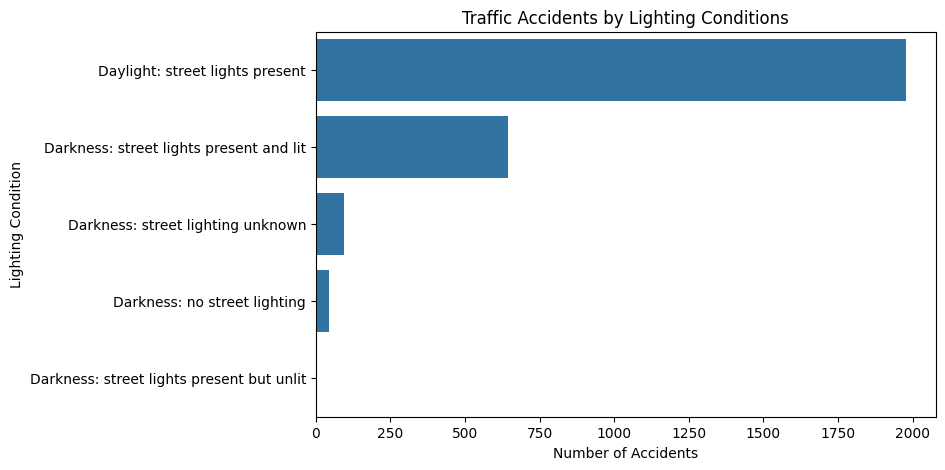

In [12]:
plt.figure(figsize=(8, 5))

lighting_counts = df["Lighting Conditions"].value_counts()

sns.barplot(
    x=lighting_counts.values,
    y=lighting_counts.index
)

plt.title("Traffic Accidents by Lighting Conditions")
plt.xlabel("Number of Accidents")
plt.ylabel("Lighting Condition")

plt.savefig("Accidents_by_Lighting_Conditions.png", bbox_inches="tight")
plt.show()

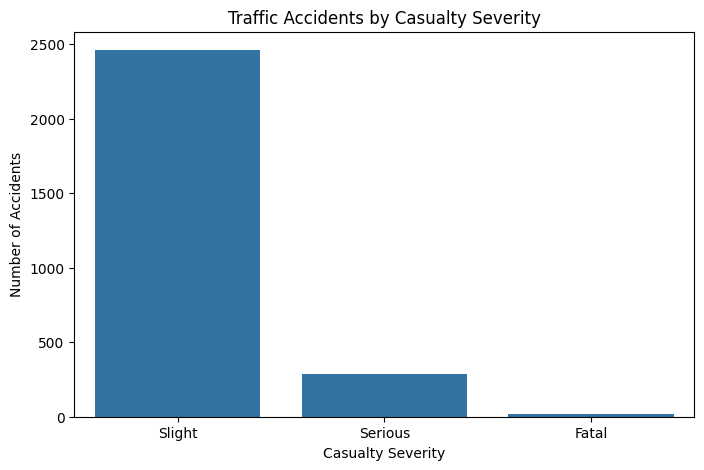

In [13]:
plt.figure(figsize=(8, 5))

severity_counts = df["Casualty Severity"].value_counts()

sns.barplot(
    x=severity_counts.index.astype(str),
    y=severity_counts.values
)

plt.title("Traffic Accidents by Casualty Severity")
plt.xlabel("Casualty Severity")
plt.ylabel("Number of Accidents")

plt.savefig("Accidents_by_Casualty_Severity.png", bbox_inches="tight")
plt.show()

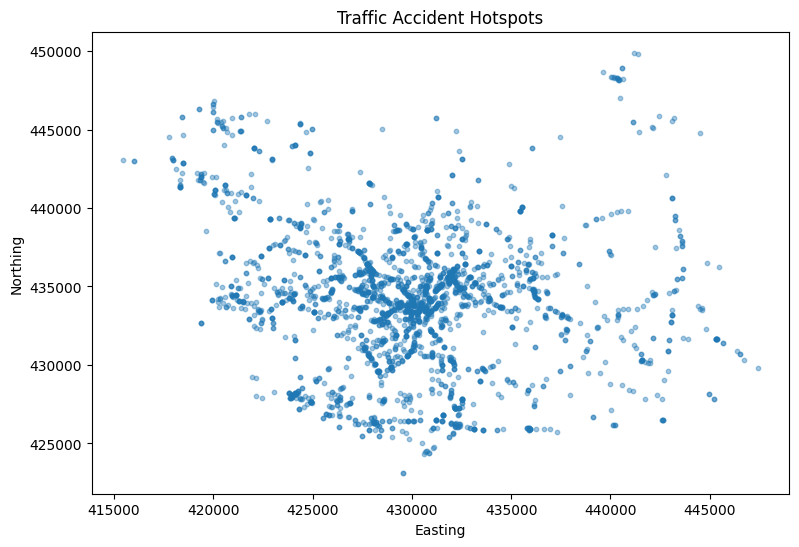

In [14]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["Easting"],
    df["Northing"],
    s=10,
    alpha=0.4
)

plt.title("Traffic Accident Hotspots")
plt.xlabel("Easting")
plt.ylabel("Northing")

plt.savefig("Accident_Hotspots.png", bbox_inches="tight")
plt.show()

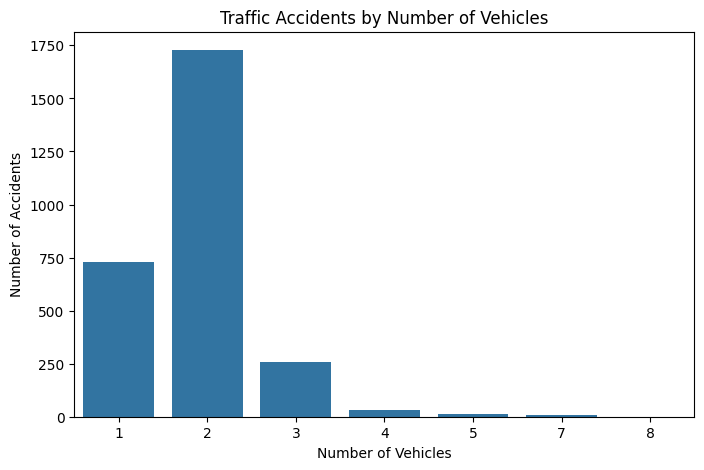

In [16]:
plt.figure(figsize=(8, 5))

vehicle_counts = df["Number of Vehicles"].value_counts().sort_index()

sns.barplot(
    x=vehicle_counts.index.astype(str),
    y=vehicle_counts.values
)

plt.title("Traffic Accidents by Number of Vehicles")
plt.xlabel("Number of Vehicles")
plt.ylabel("Number of Accidents")

plt.savefig("Accidents_by_Number_of_Vehicles.png", bbox_inches="tight")
plt.show()

In [17]:
print("===== KEY FINDINGS =====")

print("\nAccidents by Time of Day:")
print(df["Time Period"].value_counts())

print("\nAccidents by Road Surface:")
print(df["Road Surface"].value_counts())

print("\nAccidents by Weather Conditions:")
print(df["Weather Conditions"].value_counts().head(10))

print("\nAccidents by Lighting Conditions:")
print(df["Lighting Conditions"].value_counts())

print("\nAccidents by Casualty Severity:")
print(df["Casualty Severity"].value_counts())

print("\nAccidents by Number of Vehicles:")
print(df["Number of Vehicles"].value_counts().sort_index())

===== KEY FINDINGS =====

Accidents by Time of Day:
Time Period
Afternoon    972
Evening      718
Morning      675
Night        400
Name: count, dtype: int64

Accidents by Road Surface:
Road Surface
Dry           1955
Wet / Damp     663
Frost/ Ice      88
Snow            57
5                2
Name: count, dtype: int64

Accidents by Weather Conditions:
Weather Conditions
Fine without high winds       2363
Raining without high winds     236
Snowing without high winds      44
Other                           43
Fine with high winds            25
Raining with high winds         23
Unknown                         17
Fog or mist  if hazard         12
Snowing with high winds          2
Name: count, dtype: int64

Accidents by Lighting Conditions:
Lighting Conditions
Daylight: street lights present              1979
Darkness: street lights present and lit       643
Darkness: street lighting unknown              96
Darkness: no street lighting                   44
Darkness: street lights present